# Phase 1 — PTB-XL Architecture Benchmark

This notebook benchmarks 5 architectures on the same PTB-XL pipeline:
1. CNN baseline
2. CNN + LSTM
3. ResNet1D
4. InceptionTime
5. Transformer (time-series)

## Session Sections
1) Imports and setup  
2) Reproducibility and device  
3) Paths and configuration  
4) Load PTB-XL metadata  
5) EDA (distribution and durations)  
6) Signal loading helpers  
7) Label mapping and filtering  
8) Build feature/label arrays  
9) Data cleaning checks  
10) Optional signal filtering  
11) Train/val/test split  
12) Imbalance handling  
13) Data augmentation  
14) DataLoaders  
15) Architecture registry  
16) Training/evaluation utilities  
17) Train and evaluate all models  
18) Comparison, saving, and final report

In [18]:
# 1) Imports and setup
import sys
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

try:
    from scipy.signal import butter, filtfilt
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

import wfdb

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'phase1':
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

PROJECT_ROOT = /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence


In [19]:
# 2) Reproducibility and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('DEVICE =', DEVICE)

DEVICE = mps


In [20]:
# 3) Paths and configuration
DATA_ROOT = PROJECT_ROOT / 'dataset' / 'raw' / 'ptb-xl'
CSV_PATH = DATA_ROOT / 'ptbxl_database.csv'
SCP_PATH = DATA_ROOT / 'scp_statements.csv'

RESULTS_DIR = PROJECT_ROOT / 'results' / 'phase1' / 'architecture_benchmark'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLING_RATE = 100
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5

AUG_NOISE_STD = 0.01
AUG_SCALE_MIN = 0.95
AUG_SCALE_MAX = 1.05

print('DATA_ROOT =', DATA_ROOT)
print('RESULTS_DIR =', RESULTS_DIR)

DATA_ROOT = /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/raw/ptb-xl
RESULTS_DIR = /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1/architecture_benchmark


In [21]:
# 4) Load PTB-XL metadata
if not CSV_PATH.exists() or not SCP_PATH.exists():
    raise FileNotFoundError('PTB-XL files not found. Check dataset/raw/ptb-xl link/path.')

df = pd.read_csv(CSV_PATH, index_col='ecg_id')
scp_df = pd.read_csv(SCP_PATH, index_col=0)

print('Records:', len(df))
display(df.head(3))

Records: 21837


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


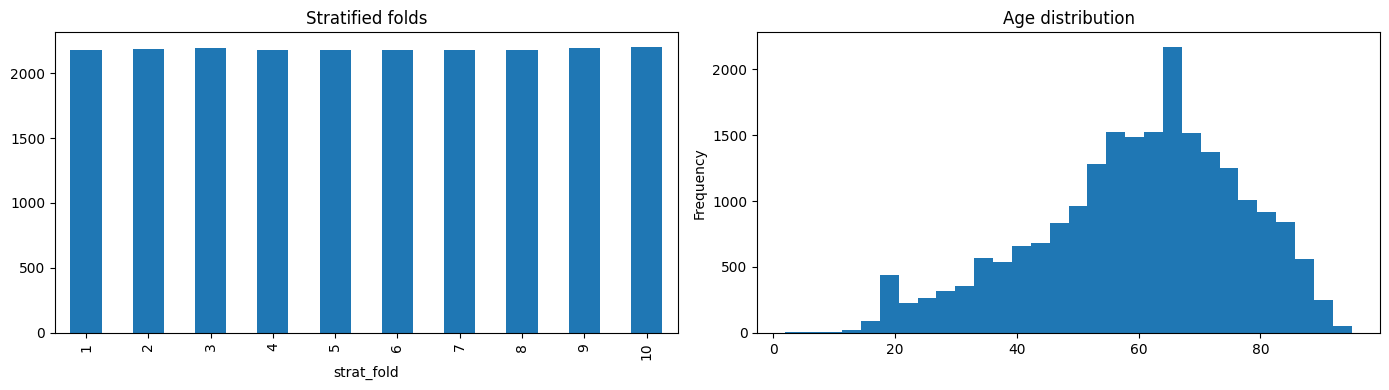

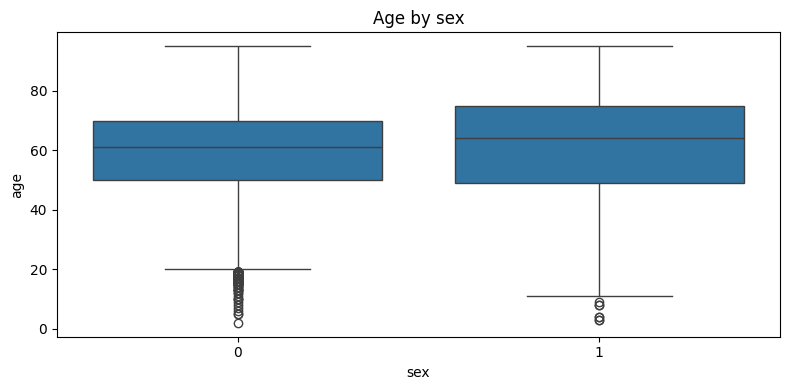

In [22]:
# 5) EDA (distribution and durations)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['strat_fold'].value_counts().sort_index().plot(kind='bar', ax=ax[0], title='Stratified folds')
df['age'].dropna().plot(kind='hist', bins=30, ax=ax[1], title='Age distribution')
plt.tight_layout()

if HAS_SEABORN:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df['sex'].fillna('unknown'), y=df['age'])
    plt.title('Age by sex')
    plt.tight_layout()

In [23]:
# 6) Signal loading helpers
import ast

def parse_scp_codes(s):
    if isinstance(s, str):
        return ast.literal_eval(s)
    return {}

df['scp_codes_dict'] = df['scp_codes'].apply(parse_scp_codes)

def load_record_signal(row, sampling_rate=100):
    rel = row['filename_lr'] if sampling_rate == 100 else row['filename_hr']
    path = DATA_ROOT / rel
    signal, _ = wfdb.rdsamp(str(path))
    return signal.astype(np.float32)

example_signal = load_record_signal(df.iloc[0], SAMPLING_RATE)
print('Example signal shape:', example_signal.shape)

Example signal shape: (1000, 12)


In [24]:
# 7) Label mapping and filtering
diagnostic_map = scp_df[scp_df['diagnostic'] == 1]['diagnostic_class'].dropna().to_dict()

def extract_diagnostic_classes(code_dict):
    classes = set()
    for code in code_dict.keys():
        if code in diagnostic_map:
            classes.add(diagnostic_map[code])
    return sorted(classes)

df['diagnostic_classes'] = df['scp_codes_dict'].apply(extract_diagnostic_classes)
df_diag = df[df['diagnostic_classes'].map(len) > 0].copy()

print('Diagnostic records:', len(df_diag))
all_labels = sorted({label for labels in df_diag['diagnostic_classes'] for label in labels})
print('Classes:', all_labels)

Diagnostic records: 21430
Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


In [25]:
# 8) Build feature/label arrays
mlb = MultiLabelBinarizer(classes=all_labels)
y_all = mlb.fit_transform(df_diag['diagnostic_classes']).astype(np.float32)

signals = []
valid_indices = []
for idx, (_, row) in enumerate(df_diag.iterrows()):
    try:
        sig = load_record_signal(row, SAMPLING_RATE)
        signals.append(sig)
        valid_indices.append(idx)
    except Exception:
        continue

X_all = np.stack(signals, axis=0)
y_all = y_all[valid_indices]

print('X_all shape:', X_all.shape)
print('y_all shape:', y_all.shape)

X_all shape: (21430, 1000, 12)
y_all shape: (21430, 5)


In [26]:
# 9) Data cleaning checks
finite_mask = np.isfinite(X_all).all(axis=(1, 2))
nonzero_mask = np.abs(X_all).sum(axis=(1, 2)) > 0
keep_mask = finite_mask & nonzero_mask

X_all = X_all[keep_mask]
y_all = y_all[keep_mask]

print('After cleaning:', X_all.shape, y_all.shape)

After cleaning: (21430, 1000, 12) (21430, 5)


In [27]:
# 10) Optional signal filtering
def bandpass_filter_batch(x, fs=100, low=0.5, high=40.0, order=3):
    if not HAS_SCIPY:
        return x
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    x_f = np.empty_like(x)
    for i in range(x.shape[0]):
        for ch in range(x.shape[2]):
            x_f[i, :, ch] = filtfilt(b, a, x[i, :, ch])
    return x_f

X_all = bandpass_filter_batch(X_all, fs=SAMPLING_RATE)
print('Filtering applied:', HAS_SCIPY)

Filtering applied: True


In [28]:
# 11) Train/val/test split
multi_label_count = y_all.sum(axis=1)
stratify_target = np.clip(multi_label_count, 0, 3).astype(int)

idx = np.arange(len(X_all))
idx_train, idx_temp = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=stratify_target)
stratify_temp = stratify_target[idx_temp]
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=SEED, stratify=stratify_temp)

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val, y_val = X_all[idx_val], y_all[idx_val]
X_test, y_test = X_all[idx_test], y_all[idx_test]

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (15001, 1000, 12) (15001, 5)
Val  : (3214, 1000, 12) (3214, 5)
Test : (3215, 1000, 12) (3215, 5)


In [29]:
# 12) Imbalance handling
label_support = y_train.sum(axis=0)
class_weights = np.ones(y_train.shape[1], dtype=np.float32)
for c in range(y_train.shape[1]):
    positives = y_train[:, c]
    if positives.sum() > 0 and (1 - positives).sum() > 0:
        w = compute_class_weight(class_weight='balanced', classes=np.array([0.0, 1.0]), y=positives)
        class_weights[c] = w[1]

sample_weights = (y_train * class_weights[None, :]).sum(axis=1) + 1e-6
sampler = WeightedRandomSampler(weights=torch.from_numpy(sample_weights).double(), num_samples=len(sample_weights), replacement=True)

print('Class support:', dict(zip(mlb.classes_, label_support.astype(int))))

Class support: {'CD': np.int64(3432), 'HYP': np.int64(1867), 'MI': np.int64(3887), 'NORM': np.int64(6655), 'STTC': np.int64(3637)}


In [30]:
# 13) Data augmentation
class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = self.y[idx]

        if self.augment:
            scale = np.random.uniform(AUG_SCALE_MIN, AUG_SCALE_MAX)
            x = x * scale
            x = x + np.random.normal(0.0, AUG_NOISE_STD, size=x.shape).astype(np.float32)

        x = torch.from_numpy(x).transpose(0, 1)
        y = torch.from_numpy(y)
        return x, y

In [14]:
# 14) DataLoaders
train_ds = ECGDataset(X_train, y_train, augment=True)
val_ds = ECGDataset(X_val, y_val, augment=False)
test_ds = ECGDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Train batches:', len(train_loader))

Train batches: 235


In [ ]:
# 15) Architecture registry
import importlib
import phase1.models.architectures.cnn_baseline as m_cnn_baseline
import phase1.models.architectures.cnn_lstm as m_cnn_lstm
import phase1.models.architectures.resnet1d as m_resnet1d
import phase1.models.architectures.inception_time as m_inception_time
import phase1.models.architectures.transformer_ts as m_transformer_ts

m_cnn_baseline = importlib.reload(m_cnn_baseline)
m_cnn_lstm = importlib.reload(m_cnn_lstm)
m_resnet1d = importlib.reload(m_resnet1d)
m_inception_time = importlib.reload(m_inception_time)
m_transformer_ts = importlib.reload(m_transformer_ts)

CNNBaseline = m_cnn_baseline.CNNBaseline
CNNLSTM = m_cnn_lstm.CNNLSTM
ResNet1D = m_resnet1d.ResNet1D
InceptionTimeClassifier = m_inception_time.InceptionTimeClassifier
TimeSeriesTransformer = m_transformer_ts.TimeSeriesTransformer

def build_model(name: str, in_channels: int, num_classes: int):
    if name == 'cnn_baseline':
        return CNNBaseline(in_channels=in_channels, num_classes=num_classes)
    if name == 'cnn_lstm':
        return CNNLSTM(in_channels=in_channels, num_classes=num_classes)
    if name == 'resnet1d':
        return ResNet1D(in_channels=in_channels, num_classes=num_classes)
    if name == 'inception_time':
        return InceptionTimeClassifier(in_channels=in_channels, num_classes=num_classes)
    if name == 'transformer_ts':
        return TimeSeriesTransformer(in_channels=in_channels, num_classes=num_classes)
    raise ValueError(f'Unknown architecture: {name}')

MODEL_NAMES = ['cnn_baseline', 'cnn_lstm', 'resnet1d', 'inception_time', 'transformer_ts']
print(MODEL_NAMES)

['cnn_baseline', 'cnn_lstm', 'resnet1d', 'inception_time', 'transformer_ts']


In [ ]:
# Quick sanity check for InceptionTime output shape consistency
x_dummy = torch.randn(4, 12, 1000, device=DEVICE)
with torch.no_grad():
    m_dummy = build_model('inception_time', in_channels=12, num_classes=y_train.shape[1]).to(DEVICE)
    y_dummy = m_dummy(x_dummy)
print('InceptionTime forward OK:', tuple(y_dummy.shape))

In [16]:
# 16) Training/evaluation utilities
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    preds_all, targets_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = (torch.sigmoid(logits) >= 0.5).float().detach().cpu().numpy()
        preds_all.append(preds)
        targets_all.append(yb.detach().cpu().numpy())

    y_true = np.vstack(targets_all)
    y_pred = np.vstack(preds_all)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return float(np.mean(losses)), acc, f1

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    preds_all, targets_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)

        losses.append(loss.item())
        preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy()
        preds_all.append(preds)
        targets_all.append(yb.cpu().numpy())

    y_true = np.vstack(targets_all)
    y_pred = np.vstack(preds_all)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return float(np.mean(losses)), acc, f1, y_true, y_pred

def fit_model(model_name: str):
    in_channels = X_train.shape[2]
    num_classes = y_train.shape[1]

    model = build_model(model_name, in_channels, num_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(class_weights, device=DEVICE))

    best_val_f1 = -1.0
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, criterion)

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss,
            'train_acc': tr_acc,
            'train_f1': tr_f1,
            'val_loss': va_loss,
            'val_acc': va_acc,
            'val_f1': va_f1,
        })

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(f'[{model_name}] epoch={epoch:02d} tr_acc={tr_acc:.4f} tr_f1={tr_f1:.4f} va_acc={va_acc:.4f} va_f1={va_f1:.4f}')
        if wait >= PATIENCE:
            print(f'[{model_name}] early stop at epoch {epoch}')
            break

    best_epoch_stats = max(history, key=lambda row: row['val_f1']) if history else None

    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc, te_f1, y_true, y_pred = evaluate(model, test_loader, criterion)

    model_dir = RESULTS_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_dir / 'best_model.pt')
    with open(model_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    summary = {
        'model': model_name,
        'best_epoch': int(best_epoch_stats['epoch']) if best_epoch_stats else None,
        'train_acc_best_epoch': float(best_epoch_stats['train_acc']) if best_epoch_stats else None,
        'val_acc_best_epoch': float(best_epoch_stats['val_acc']) if best_epoch_stats else None,
        'train_f1_best_epoch': float(best_epoch_stats['train_f1']) if best_epoch_stats else None,
        'best_val_f1': best_val_f1,
        'test_loss': te_loss,
        'test_acc': te_acc,
        'test_f1_macro': te_f1,
    }
    with open(model_dir / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    report = classification_report(y_true, y_pred, target_names=mlb.classes_, zero_division=0)
    with open(model_dir / 'classification_report.txt', 'w') as f:
        f.write(report)

    return summary, history

In [31]:
# 17) Train and evaluate all models
all_summaries = []
all_histories = {}

for model_name in MODEL_NAMES:
    summary, history = fit_model(model_name)
    all_summaries.append(summary)
    all_histories[model_name] = history

results_df = pd.DataFrame(all_summaries).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
results_df_display = results_df[[
    'model',
    'best_epoch',
    'train_acc_best_epoch',
    'val_acc_best_epoch',
    'best_val_f1',
    'test_acc',
    'test_f1_macro',
]].copy()

for col in ['train_acc_best_epoch', 'val_acc_best_epoch', 'best_val_f1', 'test_acc', 'test_f1_macro']:
    results_df_display[col] = results_df_display[col].round(4)

display(results_df_display)

[cnn_baseline] epoch=01 tr_f1=0.5903 va_f1=0.6336
[cnn_baseline] epoch=02 tr_f1=0.7037 va_f1=0.6183
[cnn_baseline] epoch=03 tr_f1=0.7183 va_f1=0.6717
[cnn_baseline] epoch=04 tr_f1=0.7319 va_f1=0.6891
[cnn_baseline] epoch=05 tr_f1=0.7354 va_f1=0.6274
[cnn_baseline] epoch=06 tr_f1=0.7410 va_f1=0.6325
[cnn_baseline] epoch=07 tr_f1=0.7465 va_f1=0.6652
[cnn_baseline] epoch=08 tr_f1=0.7523 va_f1=0.6856
[cnn_baseline] epoch=09 tr_f1=0.7566 va_f1=0.7020
[cnn_baseline] epoch=10 tr_f1=0.7570 va_f1=0.6941
[cnn_lstm] epoch=01 tr_f1=0.5417 va_f1=0.5702
[cnn_lstm] epoch=02 tr_f1=0.6469 va_f1=0.6003
[cnn_lstm] epoch=03 tr_f1=0.6860 va_f1=0.4993
[cnn_lstm] epoch=04 tr_f1=0.7036 va_f1=0.6486
[cnn_lstm] epoch=05 tr_f1=0.7243 va_f1=0.6378
[cnn_lstm] epoch=06 tr_f1=0.7348 va_f1=0.6845
[cnn_lstm] epoch=07 tr_f1=0.7476 va_f1=0.6776
[cnn_lstm] epoch=08 tr_f1=0.7597 va_f1=0.6675
[cnn_lstm] epoch=09 tr_f1=0.7613 va_f1=0.6798
[cnn_lstm] epoch=10 tr_f1=0.7733 va_f1=0.6918
[resnet1d] epoch=01 tr_f1=0.7106 va_f1=0

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 1001 but got size 1000 for tensor number 3 in the list.

In [ ]:
# 18) Comparison, saving, and final report
plt.figure(figsize=(10, 4))
plt.bar(results_df['model'], results_df['test_f1_macro'])
plt.title('Test Macro-F1 Comparison')
plt.xticks(rotation=20)
plt.tight_layout()

results_df.to_csv(RESULTS_DIR / 'architecture_comparison.csv', index=False)

best_row = results_df.iloc[0].to_dict()
final_report = {
    'best_model': best_row['model'],
    'best_test_acc': float(best_row['test_acc']),
    'best_test_f1_macro': float(best_row['test_f1_macro']),
    'all_models': all_summaries,
}

with open(RESULTS_DIR / 'final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('Best model:', final_report['best_model'])
print('Saved artifacts to:', RESULTS_DIR)